In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


In [2]:
# Load Dataset

df = pd.read_csv("../data/Retail_Transaction_Dataset.csv")

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"],format="mixed")

print(df.shape)

df.head()

(99460, 10)


,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,2025-12-26 12:32:00,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,2025-08-05 00:00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,2026-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,2025-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,2025-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [3]:
# Customer Feature Engineering
# Customer Feature Engineering

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
df = df.dropna(subset=["TransactionDate"]).sort_values("TransactionDate").reset_index(drop=True)

max_date = df["TransactionDate"].max()
observation_window_days = 90
future_window_days = 90

cutoff_date = max_date - pd.Timedelta(days=observation_window_days)

observed_df = df[df["TransactionDate"] <= cutoff_date].copy()

customer_df = (
    observed_df.groupby("CustomerID")
    .agg(
        TotalSpent=("TotalAmount", "sum"),
        TotalTransactions=("TransactionDate", "count"),
        TotalQuantity=("Quantity", "sum"),
        AverageOrderValue=("TotalAmount", "mean"),
        AverageDiscount=("DiscountApplied(%)", "mean"),
        LastPurchase=("TransactionDate", "max")
    )
    .reset_index()
)

customer_df["Recency"] = (
    cutoff_date - customer_df["LastPurchase"]
).dt.days

customer_df.drop(columns=["LastPurchase"], inplace=True)

future_df = (
    df[
        (df["TransactionDate"] > cutoff_date)
        & (df["TransactionDate"] <= cutoff_date + pd.Timedelta(days=future_window_days))
    ]
    .groupby("CustomerID")["TransactionDate"]
    .count()
    .rename("FutureTransactions")
    .reset_index()
)

customer_df = customer_df.merge(future_df, on="CustomerID", how="left")
customer_df["FutureTransactions"] = customer_df["FutureTransactions"].fillna(0)

customer_df["Churn"] = (
    customer_df["FutureTransactions"] == 0
).astype(int)

print("Observation cutoff date :", cutoff_date.strftime("%Y-%m-%d"))
print("Future window (days)    :", future_window_days)
print("\nCustomer feature table preview")
customer_df.head()


Observation cutoff date : 2026-01-28
Future window (days)    : 90

Customer feature table preview


,CustomerID,TotalSpent,TotalTransactions,TotalQuantity,AverageOrderValue,AverageDiscount,Recency,FutureTransactions,Churn
0,14,256.232791,1,5,256.232791,15.504050,175,0.0,1
1,42,502.656523,1,7,502.656523,19.191090,254,0.0,1
2,49,21.399047,1,1,21.399047,14.923377,237,0.0,1
3,59,139.612036,1,4,139.612036,6.736390,162,1.0,0
4,65,548.006625,1,8,548.006625,8.319811,224,0.0,1


In [4]:
# Prepare Features for Modeling
# Prepare Features for Modeling

features = [
    "Recency",
    "TotalTransactions",
    "TotalSpent",
    "TotalQuantity",
    "AverageOrderValue",
    "AverageDiscount"
]

X = customer_df[features]

y = customer_df["Churn"]

print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)


Feature Matrix : (72245, 6)
Target Vector  : (72245,)


In [5]:
# Review Label Distribution
# Review Label Distribution

print("\nClass Distribution")
print(y.value_counts())



Class Distribution
Churn
1    70491
0     1754
Name: count, dtype: int64


In [6]:
# Verify Feature Data
# Verify Feature Data

print("Feature columns available :", features)
print("Missing values :", customer_df[features].isna().sum().to_dict())


Feature columns available : ['Recency', 'TotalTransactions', 'TotalSpent', 'TotalQuantity', 'AverageOrderValue', 'AverageDiscount']
Missing values : {'Recency': 0, 'TotalTransactions': 0, 'TotalSpent': 0, 'TotalQuantity': 0, 'AverageOrderValue': 0, 'AverageDiscount': 0}


In [7]:
# Generate Time-Based Churn Labels
# Generate Time-Based Churn Labels

print("Churn definition : 1 if the customer has no transaction in the next 90 days after the observation cutoff")
print("Observation window :", observation_window_days, "days")
print("Future window      :", future_window_days, "days")


Churn definition : 1 if the customer has no transaction in the next 90 days after the observation cutoff
Observation window : 90 days
Future window      : 90 days


In [8]:
# Feature Selection
# Feature Selection

# The feature matrix X and label vector y were built in the previous cell.
pass


In [9]:
# Train Test Split
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])


Training Samples : 57796
Testing Samples  : 14449


In [10]:
# Train Random Forest
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")


Random Forest Trained Successfully


In [11]:
# Predictions

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Generated predictions from the time-based churn model")


Generated predictions from the time-based churn model


In [12]:
# Model Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("="*60)
print("Random Forest Model Evaluation")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

Random Forest Model Evaluation
Accuracy  : 0.9757
Precision : 0.9757
Recall    : 1.0000
F1 Score  : 0.9877
ROC-AUC   : 0.4977


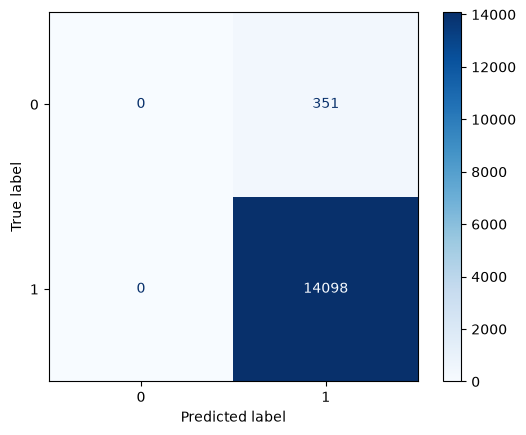


Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       351
           1       0.98      1.00      0.99     14098

    accuracy                           0.98     14449
   macro avg       0.49      0.50      0.49     14449
weighted avg       0.95      0.98      0.96     14449



In [13]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.show()

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

In [14]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,AverageDiscount,0.262547
2,TotalSpent,0.262238
4,AverageOrderValue,0.258759
0,Recency,0.158449
3,TotalQuantity,0.054929
1,TotalTransactions,0.003078


In [15]:
# Save Improved Customer Churn Dataset
# Save Improved Customer Churn Dataset

customer_df.to_csv(
    "../data/improved_customer_churn.csv",
    index=False
)

print("="*60)
print("Improved Customer Churn Dataset Saved Successfully")
print("="*60)
print("Saved As:")
print("../data/improved_customer_churn.csv")


Improved Customer Churn Dataset Saved Successfully
Saved As:
../data/improved_customer_churn.csv


In [16]:
import joblib

joblib.dump(
    rf_model,
    "../models/improved_customer_churn.pkl"
)

print("="*60)
print("Random Forest Model Saved Successfully")
print("="*60)
print("Saved As:")
print("../models/improved_customer_churn.pkl")


Random Forest Model Saved Successfully
Saved As:
../models/improved_customer_churn.pkl
